In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df=pd.read_csv('cleaned_superstore_dataset.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Time,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,0.1125




## KPI Definitions

- Total Sales: Total revenue generated  
- Total Profit: Total earnings after cost  
- Profit Margin: Profit efficiency  
- Total Orders: Number of orders  
- AOV: Average spending per order  
- Sales per Customer: Customer value  



1.Total Sales

In [11]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2297200.8603000003


2. Total Profit


In [13]:
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 286397.0216999999




3.Profit Margin



In [14]:
profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
print("Profit Margin:", profit_margin)

Profit Margin: 12.4672172403156



4.Total Orders

In [15]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


5. Average Order Value (AOV)

In [16]:
aov = df['Sales'].sum() / df['Order ID'].nunique()
print("Average Order Value:", aov)

Average Order Value: 458.61466566180883


6. Sales per Customer

In [17]:
sales_per_customer = df['Sales'].sum() / df['Customer ID'].nunique()
print("Sales per Customer:", sales_per_customer)

Sales per Customer: 2896.8484997477935


## DEEP DIVE ANALYSIS 

1.Sales Trend Over Time

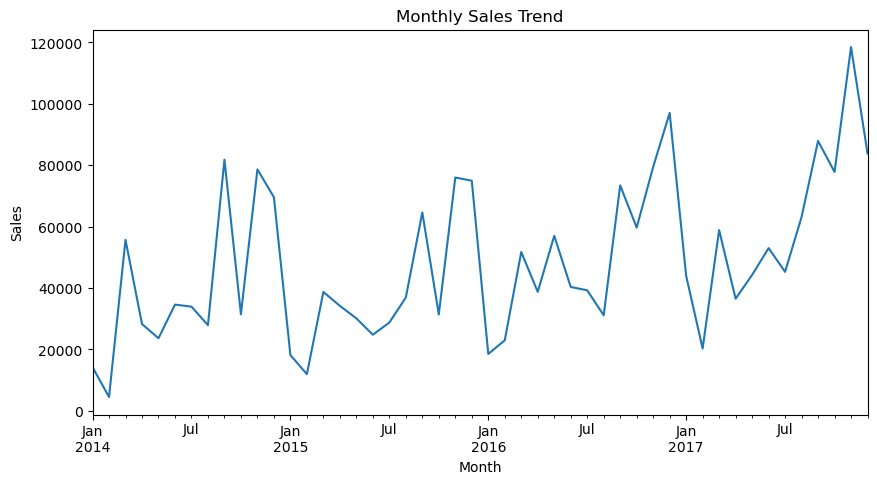

In [20]:

df['Order Date'] = pd.to_datetime(df['Order Date'])


sales_trend = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

sales_trend.plot(figsize=(10,5), title="Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

2. Sales by Category


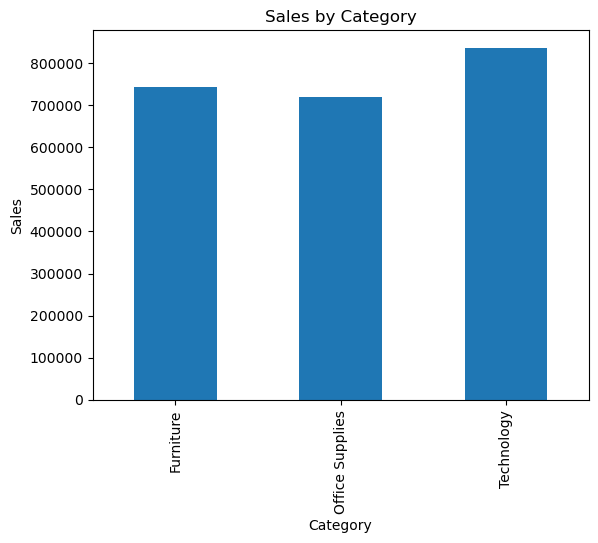

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [21]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', title="Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

print(category_sales)

3. Profit by Segment

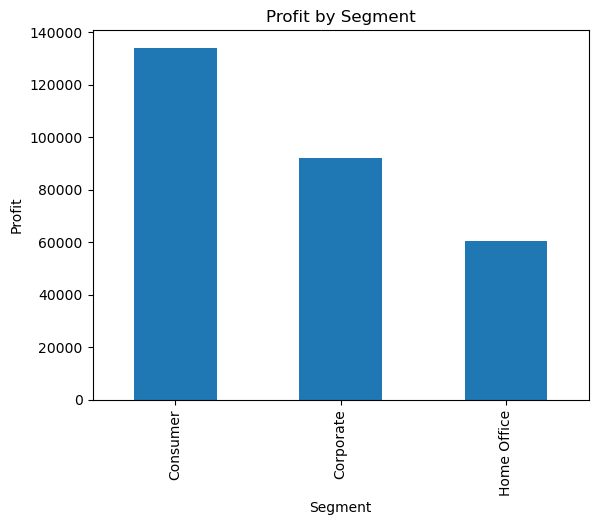

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


In [22]:
segment_profit = df.groupby('Segment')['Profit'].sum()

segment_profit.plot(kind='bar', title="Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.show()

print(segment_profit)

4. Top 10 Products

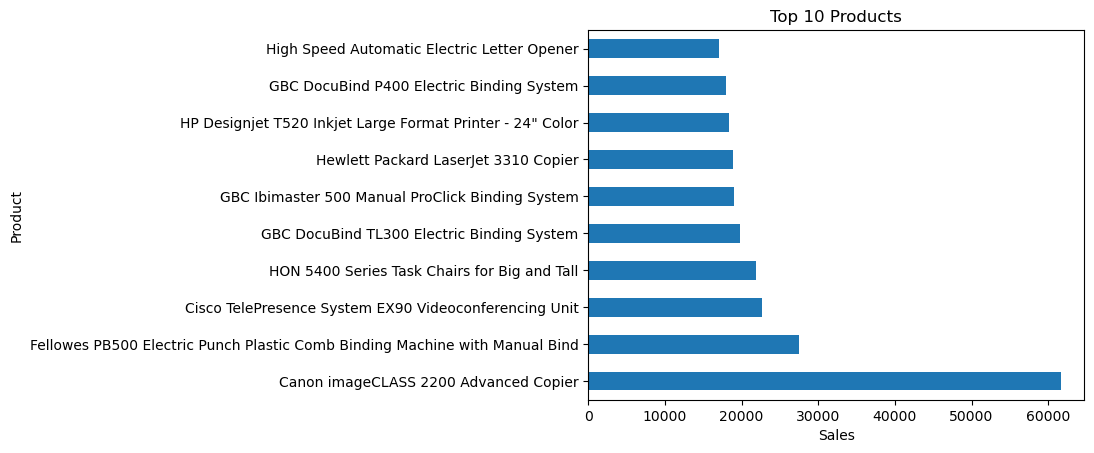

In [23]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', title="Top 10 Products")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

5. Discount vs Profit

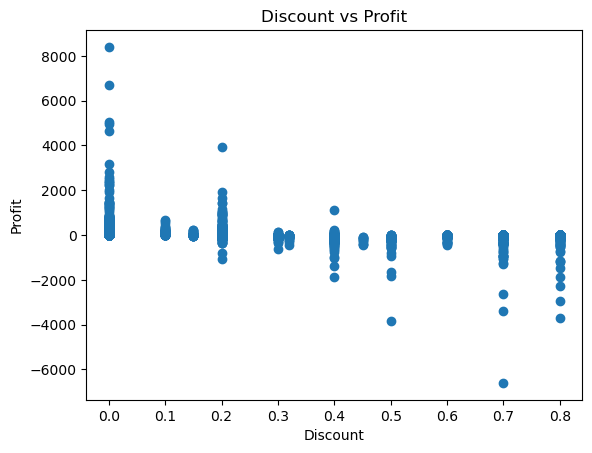

In [24]:
plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

## Deep Dive Analysis

1. Sales Trend:
Sales show variation over time indicating seasonal demand patterns.

2. Category Analysis:
Certain categories contribute more to total revenue.

3. Segment Analysis:
Some customer segments generate higher profit than others.

4. Product Analysis:
Top products contribute significantly to total sales.

5. Discount Impact:
Higher discounts negatively affect profit margins.

## Key Insights

- Sales are not consistent and show trends over time  
- Technology/Furniture category contributes highest revenue  
- Consumer segment generates most sales  
- High discounts reduce profit significantly  
- Few products dominate overall sales  